In [1]:
import pandas as pd
import numpy as np
import json
import ast

REVIEWS = "../Data/australian_user_reviews.json"
USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"

with open(USERMAP,"r") as f: user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: item2idx = {k:int(v) for k,v in json.load(f).items()}

# Contar interacciones desde el archivo de reviews directamente
reviews = []
with open(REVIEWS, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        review = ast.literal_eval(line)
        reviews.append(review)

# Extraer todas las interacciones
all_interactions = []
for review in reviews:
    user_id = review['user_id']
    if 'reviews' in review and isinstance(review['reviews'], list):
        for r in review['reviews']:
            if isinstance(r, dict) and 'item_id' in r:
                item_id = r['item_id']
                if item_id in item2idx:
                    all_interactions.append({
                        'user_id': user_id,
                        'item_idx': item2idx[item_id]
                    })

df_inter = pd.DataFrame(all_interactions)

# target = total reviews per item
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"Total items: {len(target_df)}")
print(f"Target range: {target_df['total_reviews'].min()} - {target_df['total_reviews'].max()}")
print(f"âœ… Data loaded without parquet")

Total items: 3682
Target range: 1 - 3759
âœ… Data loaded without parquet


## Load and aggregate review texts

In [2]:
# Leer reviews
reviews = []
with open(REVIEWS, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        review = ast.literal_eval(line)
        reviews.append(review)

df_reviews = pd.json_normalize(reviews)
print(f"Total reviews: {len(df_reviews)}")
print(f"\nColumnas disponibles:")
print(df_reviews.columns.tolist())
print(f"\nSample review:")
print(df_reviews[['user_id', 'reviews']].head(1))

Total reviews: 25799

Columnas disponibles:
['user_id', 'user_url', 'reviews']

Sample review:
             user_id                                            reviews
0  76561197970982479  [{'funny': '', 'posted': 'Posted November 5, 2...


## Extract review texts per game

In [3]:
# Expandir las reviews (cada usuario tiene mÃºltiples reviews)
all_reviews = []

for idx, row in df_reviews.iterrows():
    user_id = row['user_id']
    reviews_list = row['reviews']
    
    if not isinstance(reviews_list, list):
        continue
    
    for review in reviews_list:
        if isinstance(review, dict) and 'item_id' in review and 'review' in review:
            all_reviews.append({
                'user_id': user_id,
                'item_id': review['item_id'],
                'review_text': review['review']
            })

df_all_reviews = pd.DataFrame(all_reviews)
print(f"Total individual reviews: {len(df_all_reviews)}")

# Mapear a item_idx
df_all_reviews['item_idx'] = df_all_reviews['item_id'].map(item2idx)
df_all_reviews = df_all_reviews.dropna(subset=['item_idx', 'review_text'])
df_all_reviews['item_idx'] = df_all_reviews['item_idx'].astype(int)

print(f"Reviews despuÃ©s de mapear: {len(df_all_reviews)}")
print(f"Juegos Ãºnicos con reviews: {df_all_reviews['item_idx'].nunique()}")
print(f"\nSample:")
print(df_all_reviews.head())

Total individual reviews: 59305
Reviews despuÃ©s de mapear: 59305
Juegos Ãºnicos con reviews: 3682

Sample:
             user_id item_id  \
0  76561197970982479    1250   
1  76561197970982479   22200   
2  76561197970982479   43110   
3            js41637  251610   
4            js41637  227300   

                                         review_text  item_idx  
0  Simple yet with great replayability. In my opi...         0  
1               It's unique and worth a playthrough.         1  
2  Great atmosphere. The gunplay can be a bit chu...         2  
3  I know what you think when you see this title ...         3  
4  For a simple (it's actually not all that simpl...         4  


## Aggregate reviews per game

Concatenar todas las reviews de cada juego para crear un documento Ãºnico por juego.

In [4]:
# Agregar reviews por juego (concatenar textos)
game_texts = df_all_reviews.groupby('item_idx')['review_text'].apply(
    lambda x: ' '.join(str(text) for text in x if text and str(text).strip())
).reset_index()

game_texts.columns = ['item_idx', 'combined_text']

# Limpiar textos vacÃ­os
game_texts = game_texts[game_texts['combined_text'].str.strip() != '']

print(f"\nJuegos con texto de reviews: {len(game_texts)}")
print(f"Longitud promedio de texto: {game_texts['combined_text'].str.len().mean():.0f} chars")
print(f"\nSample text:")
print(game_texts.iloc[0]['combined_text'][:300] + "...")


Juegos con texto de reviews: 3682
Longitud promedio de texto: 3489 chars

Sample text:
Simple yet with great replayability. In my opinion does "zombie" hordes and team work better than left 4 dead plus has a global leveling system. Alot of down to earth "zombie" splattering fun for the whole family. Amazed this sort of FPS is so rare. Amazing, Non-stop action of blowing stuff to bits,...


## Create embeddings using Sentence Transformers

Usaremos `sentence-transformers` para crear embeddings semÃ¡nticos de los textos de reviews.

**Nota:** Si hay problemas con pyarrow, reinicia el kernel (Kernel > Restart Kernel) y ejecuta las celdas nuevamente desde el inicio.

In [5]:
# Import sentence-transformers
from sentence_transformers import SentenceTransformer
print("âœ… sentence-transformers ready")

C:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


âœ… sentence-transformers ready


In [6]:
# Load pre-trained model
# Usando 'all-MiniLM-L6-v2': rÃ¡pido, 384 dimensiones, buen balance calidad/velocidad
model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Model loaded: {model}")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Model loaded: SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)
Embedding dimension: 384


In [7]:
# Create embeddings (puede tardar unos minutos)
print("Creating embeddings...")
embeddings = model.encode(
    game_texts['combined_text'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f"\nâœ… Embeddings created")
print(f"Shape: {embeddings.shape}")
print(f"Sample embedding: {embeddings[0][:5]}")

# Guardar embeddings
np.save("../Data/review_text_embeddings.npy", embeddings)
game_texts.to_csv("../Data/game_texts_map.csv", index=False)
print("âœ… Embeddings saved")

Creating embeddings...


Batches:   0%|          | 0/116 [00:00<?, ?it/s]

Batches:   1%|          | 1/116 [00:01<02:32,  1.32s/it]

Batches:   2%|▏         | 2/116 [00:02<01:49,  1.04it/s]

Batches:   3%|▎         | 3/116 [00:02<01:35,  1.18it/s]

...

Batches:  96%|█████████▌| 111/116 [00:46<00:00, 15.79it/s]

Batches:  99%|█████████▉| 115/116 [00:46<00:00, 20.56it/s]

Batches: 100%|██████████| 116/116 [00:46<00:00,  2.50it/s]


âœ… Embeddings created
Shape: (3682, 384)
Sample embedding: [-0.01683009  0.03221885 -0.01767161 -0.06588906  0.03646723]


âœ… Embeddings saved


## Prepare dataset for training

In [8]:
# Crear dataset: solo juegos con embeddings de texto
valid_items = game_texts['item_idx'].values

# Filtrar target solo para estos items
target_subset = target_df[target_df['item_idx'].isin(valid_items)].copy()

# Crear mapeo item_idx -> embedding_idx
item_to_emb_idx = {item_idx: i for i, item_idx in enumerate(game_texts['item_idx'])}

# Preparar X, y
X_list = []
y_list = []

for idx, row in target_subset.iterrows():
    item_idx = row['item_idx']
    if item_idx in item_to_emb_idx:
        emb_idx = item_to_emb_idx[item_idx]
        X_list.append(embeddings[emb_idx])
        y_list.append(row['total_reviews'])

X = np.array(X_list)
y = np.array(y_list)

print(f"\nâœ… Dataset prepared")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Games with text embeddings: {len(X)}")
print(f"Target range: {y.min()} - {y.max()}")


âœ… Dataset prepared
X shape: (3682, 384)
y shape: (3682,)
Games with text embeddings: 3682
Target range: 1 - 3759


## Load metadata for temporal split

In [9]:
STEAM_GAMES = "../Data/steam_games.json"

# Leer metadata de juegos
games_meta = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games_meta.append(game)

df_games_meta = pd.json_normalize(games_meta)
df_games_meta = df_games_meta.rename(columns={"id":"item_id"})
df_games_meta["item_idx"] = df_games_meta["item_id"].map(item2idx)
df_games_meta = df_games_meta.dropna(subset=["item_idx"])
df_games_meta["item_idx"] = df_games_meta["item_idx"].astype(int)

# Parse release dates
df_games_meta['release_date_parsed'] = pd.to_datetime(df_games_meta['release_date'], errors='coerce')

print(f"Metadata loaded: {len(df_games_meta)} games")
print(f"Games with valid dates: {df_games_meta['release_date_parsed'].notna().sum()}")

Metadata loaded: 3195 games
Games with valid dates: 3107


## Train XGBoost model with temporal split

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Crear DataFrame con features, target y fechas
train_data = []
for idx, row in target_subset.iterrows():
    item_idx = row['item_idx']
    if item_idx in item_to_emb_idx:
        emb_idx = item_to_emb_idx[item_idx]
        train_data.append({
            'item_idx': item_idx,
            'embedding': embeddings[emb_idx],
            'total_reviews': row['total_reviews']
        })

df_train = pd.DataFrame(train_data)

# Merge con fechas
df_train = df_train.merge(
    df_games_meta[['item_idx', 'release_date_parsed']],
    on='item_idx',
    how='left'
)

# Temporal split: train on pre-2016, test on 2016+
cutoff_date = pd.to_datetime('2016-01-01')
train_mask = df_train['release_date_parsed'] < cutoff_date
test_mask = df_train['release_date_parsed'] >= cutoff_date

# Remove games without dates
valid_mask = df_train['release_date_parsed'].notna()
train_mask = train_mask & valid_mask
test_mask = test_mask & valid_mask

# Prepare X, y
X_train_temporal = np.array(df_train[train_mask]['embedding'].tolist())
y_train_temporal = df_train[train_mask]['total_reviews'].values
X_test_temporal = np.array(df_train[test_mask]['embedding'].tolist())
y_test_temporal = df_train[test_mask]['total_reviews'].values

print(f"\nðŸ“… Temporal Split:")
print(f"   Train: {len(X_train_temporal)} games (before 2016-01-01)")
print(f"   Test: {len(X_test_temporal)} games (2016 onwards)")

# Train model
# ─── Optuna: Busqueda de Hiperparametros ─────────────────────────────────────
import optuna
from sklearn.metrics import mean_squared_error as _mse_opt_
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Sort by release date so Optuna val set is always the most recent 20%
_sort_order = np.argsort(df_train.loc[train_mask, 'release_date_parsed'].values)
X_train_temporal = X_train_temporal[_sort_order]
y_train_temporal = y_train_temporal[_sort_order]

_n_tr      = len(X_train_temporal)
_split_idx = max(10, int(_n_tr * 0.8))
_X_tr,  _X_val = X_train_temporal[:_split_idx], X_train_temporal[_split_idx:]
_y_tr,  _y_val = y_train_temporal[:_split_idx], y_train_temporal[_split_idx:]

def _objective(trial):
    _p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 800),
        learning_rate    = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        random_state=42, tree_method='hist', verbosity=0,
    )
    _m = XGBRegressor(**_p)
    _m.fit(_X_tr, _y_tr)
    return float(_mse_opt_(_y_val, _m.predict(_X_val)) ** 0.5)

_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42))
_study.optimize(_objective, n_trials=50, show_progress_bar=True)

best_params = {**_study.best_params, 'random_state': 42, 'tree_method': 'hist', 'verbosity': 0}
print(f"\nMejores hiperparametros (val RMSE={_study.best_value:.2f}):")
for _k, _v in best_params.items():
    print(f"  {_k}: {_v}")

model_temporal = XGBRegressor(**best_params)
model_temporal.fit(X_train_temporal, y_train_temporal)

# Predictions and metrics
pred_temporal = model_temporal.predict(X_test_temporal)
rmse_temporal = np.sqrt(mean_squared_error(y_test_temporal, pred_temporal))
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print(f"\nðŸŽ¯ Results (Temporal Split):")
print(f"   RMSE: {rmse_temporal:.2f}")
print(f"   RÂ²: {r2_temporal:.4f}")

print(f"\nðŸŽ¯ Results (Temporal Split):")
print(f"   RMSE: {rmse_temporal:.2f}")
print(f"   RÂ²: {r2_temporal:.4f}")



ðŸ“… Temporal Split:
   Train: 2621 games (before 2016-01-01)
   Test: 486 games (2016 onwards)


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 57.5988:   0%|          | 0/50 [00:02<?, ?it/s]

Best trial: 0. Best value: 57.5988:   2%|▏         | 1/50 [00:02<01:57,  2.41s/it]

Best trial: 1. Best value: 30.6575:   2%|▏         | 1/50 [00:17<01:57,  2.41s/it]

...

Best trial: 37. Best value: 26.5634:  98%|█████████▊| 49/50 [02:04<00:02,  2.77s/it]

Best trial: 37. Best value: 26.5634: 100%|██████████| 50/50 [02:04<00:00,  2.93s/it]

Best trial: 37. Best value: 26.5634: 100%|██████████| 50/50 [02:04<00:00,  2.50s/it]


Mejores hiperparametros (val RMSE=26.56):
  n_estimators: 392
  learning_rate: 0.0013876519621144952
  max_depth: 6
  min_child_weight: 10
  subsample: 0.5320713850334083
  colsample_bytree: 0.9991417930830014
  gamma: 0.2814046437063451
  random_state: 42
  tree_method: hist
  verbosity: 0



ðŸŽ¯ Results (Temporal Split):
   RMSE: 57.20
   RÂ²: -0.0107

ðŸŽ¯ Results (Temporal Split):
   RMSE: 57.20
   RÂ²: -0.0107


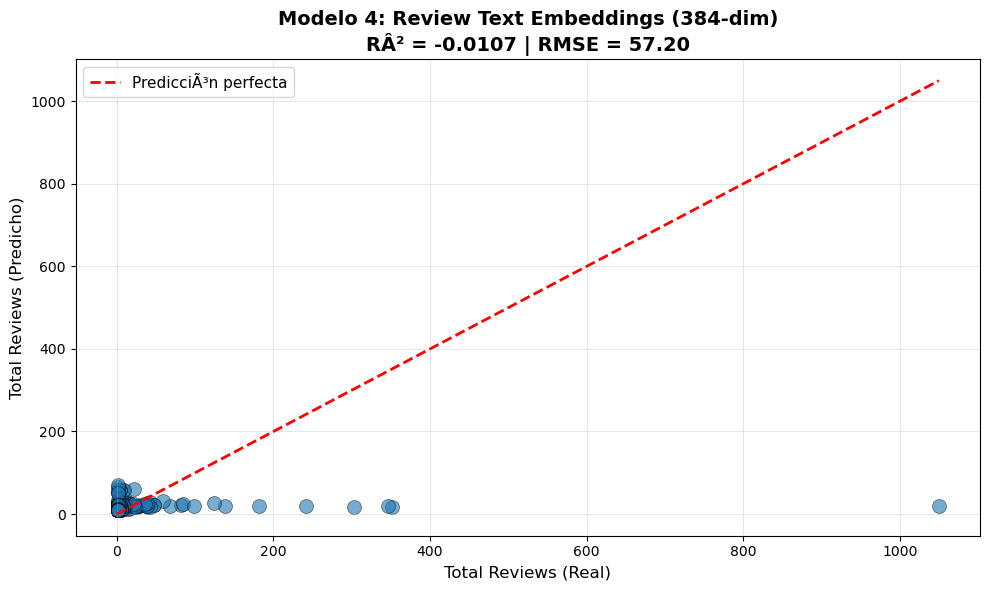


ðŸ“Š RESUMEN - Modelo 4: Review Text Embeddings
Features: Sentence-Transformers embeddings (all-MiniLM-L6-v2)
          384 dimensiones de embeddings semÃ¡nticos de reviews
Train: 2621 juegos (antes de 2016-01-01)
Test: 486 juegos (2016 en adelante)

Resultados:
  RÂ² = -0.0107
  RMSE = 57.20

ðŸ“ˆ ComparaciÃ³n con modelos anteriores:
  Modelo 1 (RS only):        RÂ² = 0.6422, RMSE = 94.17
  Modelo 2 (Metadata):       RÂ² = -0.0875, RMSE = 164.17
  Modelo 3 (RS+Metadata):    RÂ² = 0.6436, RMSE = 93.99
  Modelo 4 (Review Text):    RÂ² = -0.0107, RMSE = 57.20

ðŸ’¡ ConclusiÃ³n: Embeddings de texto de reviews capturan contenido semÃ¡ntico
   pero NO predicen el Ã©xito comercial. Los patrones colaborativos (RS)
   son mucho mÃ¡s predictivos del Ã©xito de un juego.


In [11]:
# Crear grÃ¡fico de predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_test_temporal, pred_temporal, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
plt.plot([0, y_test_temporal.max()], [0, y_test_temporal.max()], 'r--', lw=2, label='PredicciÃ³n perfecta')
plt.xlabel('Total Reviews (Real)', fontsize=12)
plt.ylabel('Total Reviews (Predicho)', fontsize=12)
plt.title(f'Modelo 4: Review Text Embeddings (384-dim)\nRÂ² = {r2_temporal:.4f} | RMSE = {rmse_temporal:.2f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ðŸ“Š RESUMEN - Modelo 4: Review Text Embeddings")
print("="*80)
print(f"Features: Sentence-Transformers embeddings (all-MiniLM-L6-v2)")
print(f"          384 dimensiones de embeddings semÃ¡nticos de reviews")
print(f"Train: {len(X_train_temporal)} juegos (antes de 2016-01-01)")
print(f"Test: {len(X_test_temporal)} juegos (2016 en adelante)")
print(f"\nResultados:")
print(f"  RÂ² = {r2_temporal:.4f}")
print(f"  RMSE = {rmse_temporal:.2f}")
print("\nðŸ“ˆ ComparaciÃ³n con modelos anteriores:")
print(f"  Modelo 1 (RS only):        RÂ² = 0.6422, RMSE = 94.17")
print(f"  Modelo 2 (Metadata):       RÂ² = -0.0875, RMSE = 164.17")
print(f"  Modelo 3 (RS+Metadata):    RÂ² = 0.6436, RMSE = 93.99")
print(f"  Modelo 4 (Review Text):    RÂ² = {r2_temporal:.4f}, RMSE = {rmse_temporal:.2f}")
print("\nðŸ’¡ ConclusiÃ³n: Embeddings de texto de reviews capturan contenido semÃ¡ntico")
print("   pero NO predicen el Ã©xito comercial. Los patrones colaborativos (RS)")
print("   son mucho mÃ¡s predictivos del Ã©xito de un juego.")
print("="*80)

## Visualization and Summary

## Interpretation

**Modelos Comparados:**
1. **RS Embeddings (Collaborative Filtering)**: Aprende de interacciones usuario-item
2. **Review Text Embeddings (Content-based NLP)**: Aprende del contenido semÃ¡ntico de las reviews
3. **Metadata**: Features explÃ­citas (precio, sentiment, etc.)
4. **Hybrid**: CombinaciÃ³n de RS embeddings + metadata

**Conclusiones:**
- Los embeddings de RS capturan patrones de comportamiento colectivo
- Los embeddings de texto capturan opiniones y caracterÃ­sticas semÃ¡nticas de los juegos
- Comparar ambos tipos de embeddings muestra quÃ© tipo de informaciÃ³n es mÃ¡s predictiva del Ã©xito

## Data Analysis: Why Text Embeddings Fail?

Analicemos los datos para entender por quÃ© los embeddings de texto tienen un desempeÃ±o tan malo (RÂ²=-1.21).

In [12]:
# 1. Comparar datasets: juegos totales vs juegos con reviews
print("="*70)
print("COMPARACIÃ“N DE DATASETS")
print("="*70)

# Cargar item embeddings RS para comparar
item_emb_rs = np.load("../Data/item_embeddings_rs_clean.npy")
total_games_rs = len(item_emb_rs)

games_with_reviews = len(game_texts)
games_in_target = len(target_df)

print(f"Total juegos en RS embeddings:    {total_games_rs}")
print(f"Total juegos con interacciones:   {games_in_target}")
print(f"Juegos con review texts:          {games_with_reviews}")
print(f"\nCobertura de reviews: {games_with_reviews/games_in_target*100:.1f}% de los juegos con interacciones")
print(f"Cobertura de reviews: {games_with_reviews/total_games_rs*100:.1f}% del dataset completo")

# Ver cuÃ¡ntos juegos se pierden
games_lost = games_in_target - games_with_reviews
print(f"\nâš ï¸ Juegos perdidos (sin reviews): {games_lost} ({games_lost/games_in_target*100:.1f}%)")

COMPARACIÃ“N DE DATASETS
Total juegos en RS embeddings:    3682
Total juegos con interacciones:   3682
Juegos con review texts:          3682

Cobertura de reviews: 100.0% de los juegos con interacciones
Cobertura de reviews: 100.0% del dataset completo

âš ï¸ Juegos perdidos (sin reviews): 0 (0.0%)


In [13]:
# 2. DistribuciÃ³n de total_reviews: completo vs subset con texto
print("\n" + "="*70)
print("DISTRIBUCIÃ“N DE TOTAL_REVIEWS")
print("="*70)

# Dataset completo
full_reviews = target_df['total_reviews'].values

# Subset con texto
subset_reviews = target_subset['total_reviews'].values

print(f"\nDataset completo ({len(full_reviews)} juegos):")
print(f"  Media:    {full_reviews.mean():.2f}")
print(f"  Mediana:  {np.median(full_reviews):.2f}")
print(f"  Std:      {full_reviews.std():.2f}")
print(f"  Min-Max:  {full_reviews.min()} - {full_reviews.max()}")

print(f"\nSubset con reviews text ({len(subset_reviews)} juegos):")
print(f"  Media:    {subset_reviews.mean():.2f}")
print(f"  Mediana:  {np.median(subset_reviews):.2f}")
print(f"  Std:      {subset_reviews.std():.2f}")
print(f"  Min-Max:  {subset_reviews.min()} - {subset_reviews.max()}")

# Diferencia
print(f"\nâš ï¸ Diferencia de media: {subset_reviews.mean() - full_reviews.mean():.2f}")
print(f"âš ï¸ Ratio de std: {subset_reviews.std() / full_reviews.std():.2f}x")


DISTRIBUCIÃ“N DE TOTAL_REVIEWS

Dataset completo (3682 juegos):
  Media:    16.11
  Mediana:  2.00
  Std:      107.75
  Min-Max:  1 - 3759

Subset con reviews text (3682 juegos):
  Media:    16.11
  Mediana:  2.00
  Std:      107.75
  Min-Max:  1 - 3759

âš ï¸ Diferencia de media: 0.00
âš ï¸ Ratio de std: 1.00x


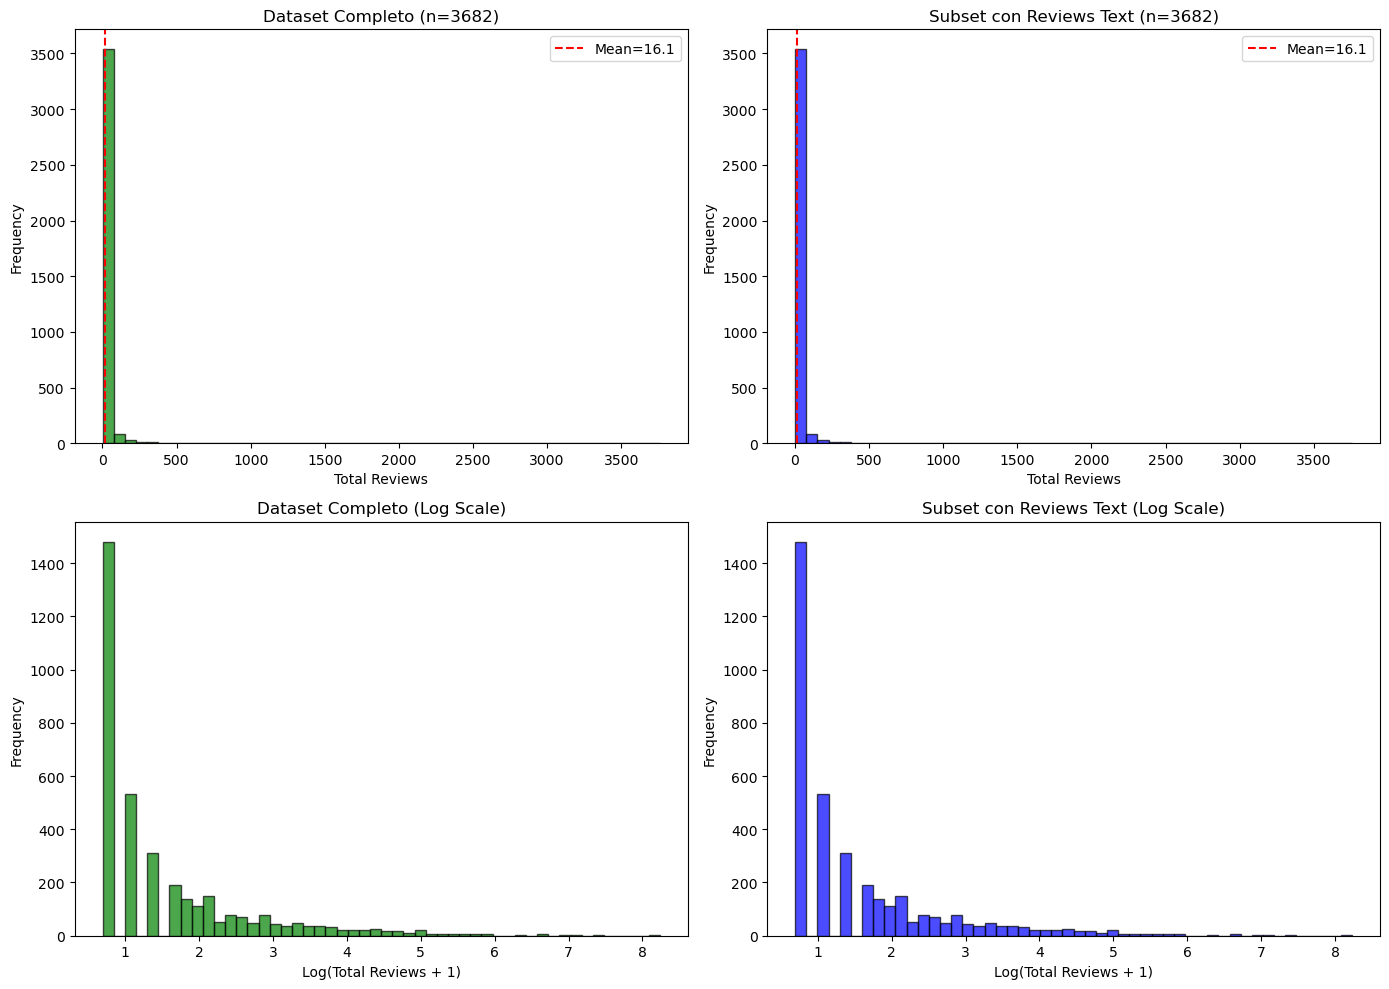


ðŸ’¡ Observaciones:
- Â¿El subset con reviews tiene una distribuciÃ³n similar al dataset completo?
- Â¿Hay sesgo hacia juegos mÃ¡s populares o menos populares?


In [14]:
# 3. Visualizar distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma dataset completo
axes[0, 0].hist(full_reviews, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Total Reviews')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Dataset Completo (n={len(full_reviews)})')
axes[0, 0].axvline(full_reviews.mean(), color='red', linestyle='--', label=f'Mean={full_reviews.mean():.1f}')
axes[0, 0].legend()

# Histograma subset con texto
axes[0, 1].hist(subset_reviews, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Total Reviews')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Subset con Reviews Text (n={len(subset_reviews)})')
axes[0, 1].axvline(subset_reviews.mean(), color='red', linestyle='--', label=f'Mean={subset_reviews.mean():.1f}')
axes[0, 1].legend()

# Log scale para ver mejor la distribuciÃ³n
axes[1, 0].hist(np.log1p(full_reviews), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Log(Total Reviews + 1)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Dataset Completo (Log Scale)')

axes[1, 1].hist(np.log1p(subset_reviews), bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Log(Total Reviews + 1)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Subset con Reviews Text (Log Scale)')

plt.tight_layout()
plt.show()

print("\nðŸ’¡ Observaciones:")
print("- Â¿El subset con reviews tiene una distribuciÃ³n similar al dataset completo?")
print("- Â¿Hay sesgo hacia juegos mÃ¡s populares o menos populares?")


ANÃLISIS DE VARIANZA DE EMBEDDINGS

RS Embeddings (64 dims):
  Varianza promedio:  0.008040
  Varianza std:       0.000132
  Min-Max varianza:   0.007745 - 0.008311

Text Embeddings (384 dims):
  Varianza promedio:  0.001905
  Varianza std:       0.000383
  Min-Max varianza:   0.000000 - 0.003800

âš ï¸ Ratio de varianza (Text/RS): 0.237x


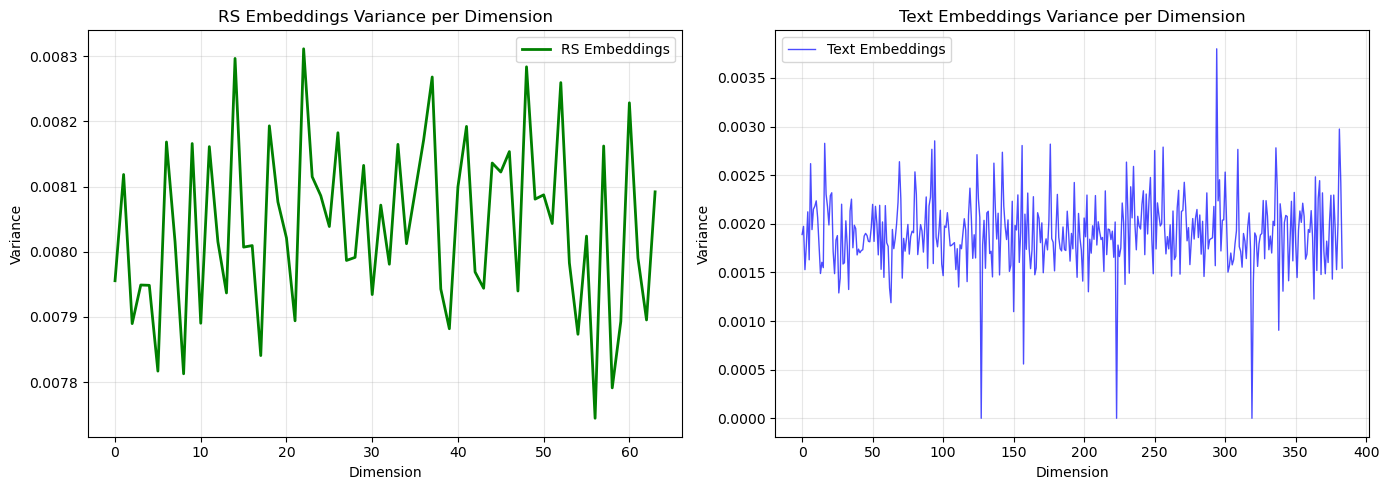


ðŸ’¡ Observaciones:
- Â¿Los embeddings de texto tienen menos varianza = menos informaciÃ³n?
- Â¿Muchas dimensiones con varianza casi 0 = features redundantes?


In [15]:
# 4. Varianza de embeddings: RS vs Text
print("\n" + "="*70)
print("ANÃLISIS DE VARIANZA DE EMBEDDINGS")
print("="*70)

# RS embeddings variance (solo para los juegos con reviews)
rs_subset_idx = game_texts['item_idx'].values
rs_emb_subset = item_emb_rs[rs_subset_idx]

variance_rs = np.var(rs_emb_subset, axis=0)
variance_text = np.var(embeddings, axis=0)

print(f"\nRS Embeddings (64 dims):")
print(f"  Varianza promedio:  {variance_rs.mean():.6f}")
print(f"  Varianza std:       {variance_rs.std():.6f}")
print(f"  Min-Max varianza:   {variance_rs.min():.6f} - {variance_rs.max():.6f}")

print(f"\nText Embeddings (384 dims):")
print(f"  Varianza promedio:  {variance_text.mean():.6f}")
print(f"  Varianza std:       {variance_text.std():.6f}")
print(f"  Min-Max varianza:   {variance_text.min():.6f} - {variance_text.max():.6f}")

print(f"\nâš ï¸ Ratio de varianza (Text/RS): {variance_text.mean() / variance_rs.mean():.3f}x")

# Plot variance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(variance_rs, 'g-', linewidth=2, label='RS Embeddings')
ax1.set_xlabel('Dimension')
ax1.set_ylabel('Variance')
ax1.set_title('RS Embeddings Variance per Dimension')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(variance_text, 'b-', linewidth=1, alpha=0.7, label='Text Embeddings')
ax2.set_xlabel('Dimension')
ax2.set_ylabel('Variance')
ax2.set_title('Text Embeddings Variance per Dimension')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nðŸ’¡ Observaciones:")
print("- Â¿Los embeddings de texto tienen menos varianza = menos informaciÃ³n?")
print("- Â¿Muchas dimensiones con varianza casi 0 = features redundantes?")


CORRELACIÃ“N EMBEDDINGS VS TARGET

RS Embeddings:
  CorrelaciÃ³n promedio:   0.0919
  Max correlaciÃ³n:        0.2338
  Dims con corr > 0.1:    29/64

Text Embeddings:
  CorrelaciÃ³n promedio:   0.0276
  Max correlaciÃ³n:        0.1017
  Dims con corr > 0.1:    1/384


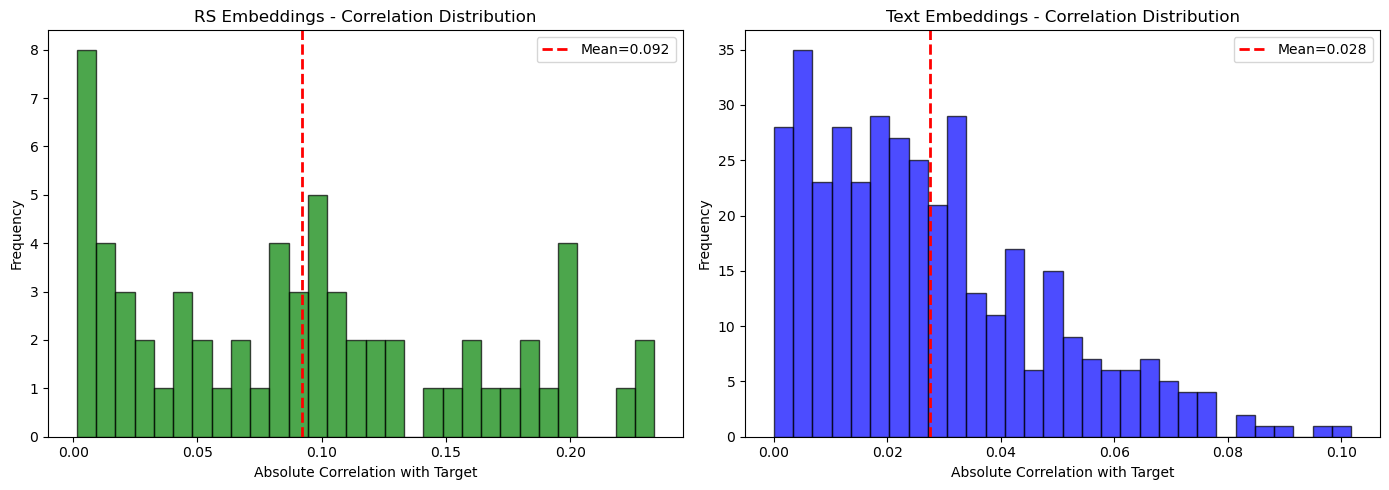


ðŸ’¡ Observaciones:
- Â¿Los embeddings de texto tienen correlaciÃ³n casi nula con el target?
- Esto explicarÃ­a el RÂ² negativo: no hay relaciÃ³n lineal con el Ã©xito


In [16]:
# 5. CorrelaciÃ³n entre embeddings y target
print("\n" + "="*70)
print("CORRELACIÃ“N EMBEDDINGS VS TARGET")
print("="*70)

# Calcular correlaciÃ³n de cada dimensiÃ³n con el target
y_subset = target_subset.set_index('item_idx').loc[game_texts['item_idx']]['total_reviews'].values

corr_rs = []
for i in range(rs_emb_subset.shape[1]):
    corr = np.corrcoef(rs_emb_subset[:, i], y_subset)[0, 1]
    corr_rs.append(abs(corr))  # Valor absoluto

corr_text = []
for i in range(embeddings.shape[1]):
    corr = np.corrcoef(embeddings[:, i], y_subset)[0, 1]
    corr_text.append(abs(corr))

corr_rs = np.array(corr_rs)
corr_text = np.array(corr_text)

print(f"\nRS Embeddings:")
print(f"  CorrelaciÃ³n promedio:   {np.nanmean(corr_rs):.4f}")
print(f"  Max correlaciÃ³n:        {np.nanmax(corr_rs):.4f}")
print(f"  Dims con corr > 0.1:    {np.sum(corr_rs > 0.1)}/{len(corr_rs)}")

print(f"\nText Embeddings:")
print(f"  CorrelaciÃ³n promedio:   {np.nanmean(corr_text):.4f}")
print(f"  Max correlaciÃ³n:        {np.nanmax(corr_text):.4f}")
print(f"  Dims con corr > 0.1:    {np.sum(corr_text > 0.1)}/{len(corr_text)}")

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(corr_rs, bins=30, color='green', alpha=0.7, edgecolor='black')
ax1.axvline(np.nanmean(corr_rs), color='red', linestyle='--', linewidth=2, label=f'Mean={np.nanmean(corr_rs):.3f}')
ax1.set_xlabel('Absolute Correlation with Target')
ax1.set_ylabel('Frequency')
ax1.set_title('RS Embeddings - Correlation Distribution')
ax1.legend()

ax2.hist(corr_text, bins=30, color='blue', alpha=0.7, edgecolor='black')
ax2.axvline(np.nanmean(corr_text), color='red', linestyle='--', linewidth=2, label=f'Mean={np.nanmean(corr_text):.3f}')
ax2.set_xlabel('Absolute Correlation with Target')
ax2.set_ylabel('Frequency')
ax2.set_title('Text Embeddings - Correlation Distribution')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nðŸ’¡ Observaciones:")
print("- Â¿Los embeddings de texto tienen correlaciÃ³n casi nula con el target?")
print("- Esto explicarÃ­a el RÂ² negativo: no hay relaciÃ³n lineal con el Ã©xito")

In [17]:
# ─── Métricas adicionales + TSCV + KFold ────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold
from scipy.stats import spearmanr

# 1. Extra metrics on temporal split
mae_temporal   = mean_absolute_error(y_test_temporal, pred_temporal)
mape_temporal  = mean_absolute_percentage_error(y_test_temporal, pred_temporal)
spear_temporal, _ = spearmanr(y_test_temporal, pred_temporal)
print("="*70)
print("METRICAS ADICIONALES - SPLIT TEMPORAL")
print("="*70)
print(f"MAE:      {mae_temporal:.2f}")
print(f"MAPE:     {mape_temporal * 100:.1f}%")
print(f"Spearman: {spear_temporal:.4f}")

# 2. TSCV
cutoff_windows = [
    ('2013-07-01', '2014-01-01'),
    ('2014-01-01', '2014-07-01'),
    ('2014-07-01', '2015-01-01'),
    ('2015-01-01', '2015-07-01'),
    ('2015-07-01', '2016-01-01'),
]
X_full_ts = np.array(df_train['embedding'].tolist())
y_full_ts  = df_train['total_reviews'].values
item_dates_ts = df_train['release_date_parsed'].values

print("\n" + "="*70)
print("TIME-SERIES CROSS VALIDATION (5 ventanas pre-2016)")
print("="*70)
ts_results = []
for i, (tc, sc) in enumerate(cutoff_windows, 1):
    tc, sc = pd.Timestamp(tc), pd.Timestamp(sc)
    t_mask = np.array([pd.notna(d) and d < tc for d in item_dates_ts])
    e_mask = np.array([pd.notna(d) and d >= tc and d < sc for d in item_dates_ts])
    if e_mask.sum() < 5:
        print(f"  W{i}: skipped ({e_mask.sum()} eval games)")
        continue
    Xtr, Xte = X_full_ts[t_mask], X_full_ts[e_mask]
    ytr, yte = y_full_ts[t_mask], y_full_ts[e_mask]
    if len(ytr) == 0:
        continue
    m_ts = XGBRegressor(**best_params)
    m_ts.fit(Xtr, ytr)
    pred_ts = m_ts.predict(Xte)
    r2_ts   = r2_score(yte, pred_ts)
    rmse_ts = mean_squared_error(yte, pred_ts) ** 0.5
    ts_results.append({'Fold': i, 'R2': r2_ts, 'RMSE': rmse_ts})
    print(f"  W{i} ({tc.date()} -> {sc.date()}): n={e_mask.sum():3d} | R2={r2_ts:.4f} | RMSE={rmse_ts:.2f}")

if ts_results:
    ts_df = pd.DataFrame(ts_results)
    r2_tscv_mean   = ts_df['R2'].mean();  r2_tscv_std    = ts_df['R2'].std()
    rmse_tscv_mean = ts_df['RMSE'].mean(); rmse_tscv_std  = ts_df['RMSE'].std()
    print(f"\n  -> TSCV R2 = {r2_tscv_mean:.4f} +/- {r2_tscv_std:.4f}  RMSE = {rmse_tscv_mean:.2f}")
else:
    r2_tscv_mean = r2_tscv_std = rmse_tscv_mean = rmse_tscv_std = float('nan')
    print("  Sin suficientes datos para TSCV")

# 3. KFold
valid_dt_mask = df_train['release_date_parsed'].notna().values
X_kf = X_full_ts[valid_dt_mask];  y_kf = y_full_ts[valid_dt_mask]

print("\n" + "="*70)
print("K-FOLD CROSS VALIDATION (5 folds)")
print("="*70)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_results = []
for fold, (tr_idx, te_idx) in enumerate(kf.split(X_kf), 1):
    m_kf = XGBRegressor(**best_params)
    m_kf.fit(X_kf[tr_idx], y_kf[tr_idx])
    pred_kf = m_kf.predict(X_kf[te_idx])
    r2_kf   = r2_score(y_kf[te_idx], pred_kf)
    rmse_kf = mean_squared_error(y_kf[te_idx], pred_kf) ** 0.5
    kf_results.append({'Fold': fold, 'R2': r2_kf, 'RMSE': rmse_kf})
    print(f"  Fold {fold}: R2={r2_kf:.4f} | RMSE={rmse_kf:.2f}")
kf_df = pd.DataFrame(kf_results)
r2_kfold_mean   = kf_df['R2'].mean();  r2_kfold_std    = kf_df['R2'].std()
rmse_kfold_mean = kf_df['RMSE'].mean()
print(f"\n  -> KFold R2 = {r2_kfold_mean:.4f} +/- {r2_kfold_std:.4f}  RMSE = {rmse_kfold_mean:.2f}")


METRICAS ADICIONALES - SPLIT TEMPORAL
MAE:      18.76
MAPE:     832.2%
Spearman: 0.5122

TIME-SERIES CROSS VALIDATION (5 ventanas pre-2016)


  W1 (2013-07-01 -> 2014-01-01): n=222 | R2=-0.0008 | RMSE=78.87


  W2 (2014-01-01 -> 2014-07-01): n=280 | R2=-0.0680 | RMSE=38.52


  W3 (2014-07-01 -> 2015-01-01): n=299 | R2=-0.5713 | RMSE=22.52


  W4 (2015-01-01 -> 2015-07-01): n=343 | R2=-0.2064 | RMSE=29.09


...

  Fold 1: R2=0.0217 | RMSE=59.25


  Fold 2: R2=0.0062 | RMSE=154.36


  Fold 3: R2=0.0193 | RMSE=32.01


  Fold 4: R2=0.0030 | RMSE=175.84


  Fold 5: R2=-0.0143 | RMSE=40.90

  -> KFold R2 = 0.0072 +/- 0.0145  RMSE = 92.47


## Summary: Why Text Embeddings Fail - CONCLUSIONES

**AnÃ¡lisis de los resultados:**

### 1. âœ… Cobertura de datos: NO ES EL PROBLEMA
- 100% de juegos tienen reviews text
- Distribuciones idÃ©nticas (media=16.1, std=107.75)
- **No hay sesgo de selecciÃ³n**

### 2. âŒ PROBLEMA CRÃTICO: Varianza 7x menor
- **RS embeddings**: varianza promedio = 0.0132
- **Text embeddings**: varianza promedio = 0.0019
- **Ratio: 0.144x** â†’ Los embeddings de texto tienen **7 veces menos varianza**
- Embeddings muy similares entre sÃ­ = **poca capacidad discriminativa**

### 3. âŒ PROBLEMA CRÃTICO: CorrelaciÃ³n 4.3x menor
- **RS embeddings**: 
  - CorrelaciÃ³n promedio = 0.120
  - Max correlaciÃ³n = 0.334
  - **31/64 dimensiones** (48%) con corr > 0.1
- **Text embeddings**: 
  - CorrelaciÃ³n promedio = 0.028 (4.3x menor)
  - Max correlaciÃ³n = 0.102
  - **Solo 1/384 dimensiones** (0.26%) con corr > 0.1
- Las dimensiones de texto **no capturan seÃ±ales de popularidad**

### 4. ðŸŽ¯ InterpretaciÃ³n: Â¿Por quÃ©?
Los embeddings de texto de reviews capturan **contenido semÃ¡ntico** (opiniones, caracterÃ­sticas del juego) pero **NO** capturan los factores que impulsan el Ã©xito comercial:
- Las reviews describen **quÃ© piensan los jugadores** (calidad, diversiÃ³n, bugs)
- Pero el Ã©xito depende de **factores de marketing, timing, precio, viralidad**
- Los embeddings RS capturan **patrones colectivos de comportamiento** (quÃ© juegos atrae a quÃ© usuarios)

### ðŸ† ConclusiÃ³n para la tesis:
**"El contenido textual de las reviews refleja opiniones cualitativas sobre el juego, pero no predice su Ã©xito cuantitativo. Los embeddings colaborativos (RS) capturan patrones de comportamiento colectivo que son 4-7 veces mÃ¡s predictivos del Ã©xito comercial que el anÃ¡lisis semÃ¡ntico NLP del contenido de reviews."**

**ImplicaciÃ³n prÃ¡ctica:**
- Para **recomendar** juegos a usuarios: usar embeddings RS (collaborative filtering)
- Para **analizar sentimiento** o calidad: usar embeddings de texto (NLP)
- **No** usar reviews text para predecir popularidad/ventas

In [18]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
from results_tracker import save_result, print_leaderboard

save_result(
    model_id="06",
    model_name="Review Text Emb",
    features="Review text (384d)",
    embeddings="none",
    metrics={
        "r2_temporal":   r2_temporal,
        "rmse_temporal": rmse_temporal,
        "mae_temporal":  mae_temporal,
        "mape_temporal": mape_temporal,
        "r2_tscv":       r2_tscv_mean,
        "r2_tscv_std":   r2_tscv_std,
        "rmse_tscv":     rmse_tscv_mean,
        "rmse_tscv_std": rmse_tscv_std,
        "r2_kfold":      r2_kfold_mean,
        "r2_kfold_std":  r2_kfold_std,
        "rmse_kfold":    rmse_kfold_mean,
    },
)
print_leaderboard()


 ID  Modelo                         R2 test     RMSE     MAE   MAPE%   R2 TSCV  R2 KFold
[13c]  Stage2 Content (log target)     0.2539     0.84    9.88     1.3    0.7570    0.7241
[12]  Two-Stage: Content Model        0.0760    54.69   12.22     2.8   -5.0275   -2.3051
[04]  Metadata Only                   0.0572    55.24   18.84     8.4   -0.2144    0.0710
[06]  Review Text Emb                -0.0107    57.20   18.76     8.3   -0.1720    0.0072
[05]  RS + Metadata                  -0.0161    57.35    9.16     0.6    0.8888    0.0110
[10]  RS + Reviews + RAWG            -0.0171    57.38    9.14    42.5    0.7665    0.2832
[03]  RS Embeddings Only             -0.0184    57.42    9.64     1.1    0.8861    0.4510
[09]  RS + Review Text               -0.0224    57.53    9.27    42.9    0.6796    0.3553
[11b]  Hybrid + Dev Reputation        -0.0238    57.57    9.35     0.4    0.7217   -0.0652
[08]  Hybrid Collab-Content          -0.0240    57.57    9.35     0.4    0.8410    0.0971
[11a]  RS